## Puprose of Notebook ## 

Matching DES SNIa to host galaxies listed as part of the DR1 DESI data release. 

## Content of DESI Galaxy Metadata Files ##



Please note that in this notebook there are two .fits files:

- `desi_galaxy_metadata_dark.fits`
-  `desi_galaxy_metadata.fits`

These files were filtered out from the main raw data files found at: 

https://data.desi.lbl.gov/public/dr1/

What Each Collumn of raw .fits files means: https://fastspecfit.readthedocs.io/en/stable/fastspec.html


The filtering consisted of getting out only galaxy related information from agregate data 
that was part of both the dark and bright iron fits survey.

The original desi data contained Qasuars Stars and Galaxies. The filtering work done here 
involved only looking at the Galaxy data and taking out the following parameters:

['TARGETID', 'RA', 'DEC', 'DESI_TARGET', 'SPECTYPE', 'Z', 'ZWARN']

For the work on how this was done please refer to:

`DES5YR_DESI_explore.ipynb`

## More detials on how data was sourced: ##

The reference for the following description is the following paper: https://arxiv.org/abs/2503.14745

Within each survey, objects are observed in one of three possible programs, depending on the acceptable lunar phase and on-sky observing conditions:

- **bright** — Observed during bright time (e.g., near full Moon)
- **dark** — Observed during dark time (e.g., new Moon)
- **backup** — Observed when conditions are not ideal for primary programs

I chose to focus only on the bright and dark survey. This is where the two data files end up coming from. Backup data set was ignored b/c it contained secondary and tertiary targets.

### Spectroscopic Production in DESI DR1 - IRON

Spectroscopic production: full, systematic data processing pipeline run on a defined set of raw DESI spectroscopic exposures. Each production results in calibrated spectra, redshifts, and other derived quantities that are released for public use and scientific analysis.

The primary spectroscopic production for DR1 is called **Iron**, named after the Iron Mountain in Utah. This production includes data from the first 13 months of the DESI main survey, as well as a uniform reprocessing of the Science Validation (SV) data that was previously part of the Early Data Release (EDR). 

In addition to Iron, DR1 also includes a supplemental production called **Guadalupe** (named after the Guadalupe Mountains in Texas), which contains data from just the first two months of the main survey. Although Guadalupe was used in early DESI analyses, it was processed using the same calibration and software as the older Fuji production used in the EDR. As such, Iron should be preferred over Guadalupe for any current or future work, due to its broader coverage and superior data processing quality.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table, hstack, vstack  # <-- added vstack here
from matplotlib.colors import LogNorm
from matplotlib.patches import Patch
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u

# ZTF Host Galaxy Coordiantes #

The ZTF DR2 releases its host galaxy coordiantes in a separate .csv to the one that lits light curve parameters. So the following code is just there to stich together the `ZTF_snia_data.csv` and `globalhost_data.csv` and `localhost_data.csv`



In [7]:
snia_path = "data/ZTF_snia_data.csv"
host_path = "data/globalhost_data.csv"
local_path = "data/localhost_data.csv"

df_snia = pd.read_csv(snia_path)
df_host = pd.read_csv(host_path)
df_local = pd.read_csv(local_path)

# Blanket rename: suffix all columns except the merge key
for c in df_host.columns:
    if c != "ztfname":
        df_host = df_host.rename(columns={c: c + "_global"})
        
for c in df_local.columns:
    if c != "ztfname":
        df_local = df_local.rename(columns={c: c + "_local"})

# Merge on ztfname
# Left Merge: keep every row from the left table (df_snia), 
# and if a matching ztfname exists in the right table (df_host), 
# attach those columns. If there's no match, the right-side columns get filled with NaN.
df_merged = pd.merge(df_snia, df_host, on="ztfname", how="left")
df_merged = pd.merge(df_merged, df_local, on="ztfname", how="left")


# Rename the prefix of the ZTF side of the data. Will come in handy when it comes to
# matching our data with DESI Galaxy catalogue later.
# 
for c in df_merged.columns:
    if c != "ztfname":
        df_merged = df_merged.rename(columns={c: "ZTF_" + c})
        
# df_merged.to_csv("data/ZTF_snia_dr2_info_complete.csv", index=False)

# Checking to make sure that everything got printed as it should have. 
print(df_merged.columns.tolist())

['ZTF_Unnamed: 0', 'ztfname', 'ZTF_redshift', 'ZTF_redshift_err', 'ZTF_source', 'ZTF_t0', 'ZTF_x0', 'ZTF_x1', 'ZTF_c', 'ZTF_t0_err', 'ZTF_x0_err', 'ZTF_x1_err', 'ZTF_c_err', 'ZTF_cov_t0_x0', 'ZTF_cov_t0_x1', 'ZTF_cov_t0_c', 'ZTF_cov_x0_x1', 'ZTF_cov_x0_c', 'ZTF_cov_x1_c', 'ZTF_mwebv', 'ZTF_mwr_v', 'ZTF_mwebv_err', 'ZTF_fitprob', 'ZTF_ra', 'ZTF_dec', 'ZTF_sn_type', 'ZTF_sub_type', 'ZTF_lccoverage_flag', 'ZTF_fitquality_flag', 'ZTF_iau_name', 'ZTF_frac_fitted', 'ZTF_ra_host_global', 'ZTF_dec_host_global', 'ZTF_mass_global', 'ZTF_mass_err_global', 'ZTF_restframe_gz_global', 'ZTF_restframe_gz_err_global', 'ZTF_d_dlr_global', 'ZTF_mass_local', 'ZTF_mass_err_local', 'ZTF_restframe_gz_local', 'ZTF_restframe_gz_err_local']


# Check for Null Entries #

Looks like light curve parameters and some mass features are null we will have to drop them. 

In [12]:
print(df_merged.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3628 entries, 0 to 3627
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ZTF_Unnamed: 0               3628 non-null   int64  
 1   ztfname                      3628 non-null   object 
 2   ZTF_redshift                 3628 non-null   float64
 3   ZTF_redshift_err             3628 non-null   float64
 4   ZTF_source                   3628 non-null   object 
 5   ZTF_t0                       3592 non-null   float64
 6   ZTF_x0                       3576 non-null   float64
 7   ZTF_x1                       3576 non-null   float64
 8   ZTF_c                        3576 non-null   float64
 9   ZTF_t0_err                   3576 non-null   float64
 10  ZTF_x0_err                   3576 non-null   float64
 11  ZTF_x1_err                   3576 non-null   float64
 12  ZTF_c_err                    3576 non-null   float64
 13  ZTF_cov_t0_x0     

### Dropping Null Entreis ###
Now that we have merged the data sets lets see how many of the SNIa have host coordinates and how many do not. 

In [17]:
# Drops the entries where ra_host OR the dec_host are missing:
df_merged_wt_hosts = df_merged.dropna(subset=["ZTF_ra_host_global", "ZTF_dec_host_global"]).copy()

print(f"Before drop: {len(df_merged)} rows")
print(f"After drop:  {len(df_merged_wt_hosts)} rows")
print(f"Dropped:     {len(df_merged) - len(df_merged_wt_hosts)} rows (missing host coordinates)")

# Drops the entries where any of the light curve parameters are missing:



Before drop: 3628 rows
After drop:  3545 rows
Dropped:     83 rows (missing host coordinates)


### Separating Missing LC Data ###

Now that we have the host coordiante ZTF data set. I noticed that certain entries have missing light curve parameters. We will end up removing those entries as well. 

In [6]:
# ---- Paths ----
merged_path = "ZTF_DESI_data/ZTF_snia_with_hosts_ONLY.csv"
out_has    = "ZTF_DESI_data/ZTF_snia_with_hosts_AND_SALT2.csv"
out_miss   = "ZTF_DESI_data/ZTF_snia_with_hosts_MISSING_SALT2.csv"

# Read the file
df = pd.read_csv(merged_path)

# ---- SALT2 block to require ----
salt2_cols = [
    "t0", "x0", "x1", "c",
    "t0_err", "x0_err", "x1_err", "c_err",
    "cov_t0_x0", "cov_t0_x1", "cov_t0_c",
    "cov_x0_x1", "cov_x0_c", "cov_x1_c",
]

# ---- Masks ----
# .notna() is only true where values aren't missing
# axis=1 → operate across columns for each row
mask_present = df[salt2_cols].notna().all(axis=1)
mask_finite  = np.isfinite(df[salt2_cols]).all(axis=1)
mask_good    = mask_present & mask_finite  # combined mask

# Split into good vs bad
df_good = df[mask_good].copy()
df_bad  = df[~mask_good].copy()

# Save out
df_good.to_csv(out_has, index=False)
df_bad.to_csv(out_miss, index=False)

print("Total rows:", len(df))
print("Good (has all SALT2 params):", len(df_good))
print("Missing any SALT2 params:", len(df_bad))

# Diagnostics: which SALT2 fields are most often missing
# ~mask good refers to rows, and salt2_cols are the columsn. 
# this way we get a data frame of just collumns with missing entreis.

# Subset: only the "bad" rows and the SALT2 columns
bad_rows = df.loc[~mask_good, salt2_cols]

# Boolean mask: True where values are missing
missing_flags = bad_rows.isna()

# Count how many missing values per column
missing_per_column = missing_flags.sum(axis=0)

# Display counts (unsorted)
print("\nMissing SALT2 fields among the 'bad' rows:")
print(missing_per_column)

Total rows: 3545
Good (has all SALT2 params): 3494
Missing any SALT2 params: 51

Missing SALT2 fields among the 'bad' rows:
t0           35
x0           51
x1           51
c            51
t0_err       51
x0_err       51
x1_err       51
c_err        51
cov_t0_x0    51
cov_t0_x1    51
cov_t0_c     51
cov_x0_x1    51
cov_x0_c     51
cov_x1_c     51
dtype: int64


### Defining a function that converts RA/DEC from degrees to Mollweide-friendly radians ###

This is done because when we plot a molleweide projection later the function responsible for it only takes in radians as arguments.

Note: this is pretty counter-intuitive because the function is after all: displaying our output in degrees 🤣.


In [7]:
def prepare_coords(ra_deg, dec_deg):
    """Convert RA/DEC from degrees to Mollweide-friendly radians."""
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)
    ra = np.remainder(ra + 2*np.pi, 2*np.pi)
    ra[ra > np.pi] -= 2*np.pi
    return -ra, dec

### Making a Plot of ZTF SNIa host galaxy locations vs. the bright and dark galaxies from DESI ###

It looks like there are not host galaxy info given as part of the ZTF data release. But we can still plot SNIa locations and see what is going on. 

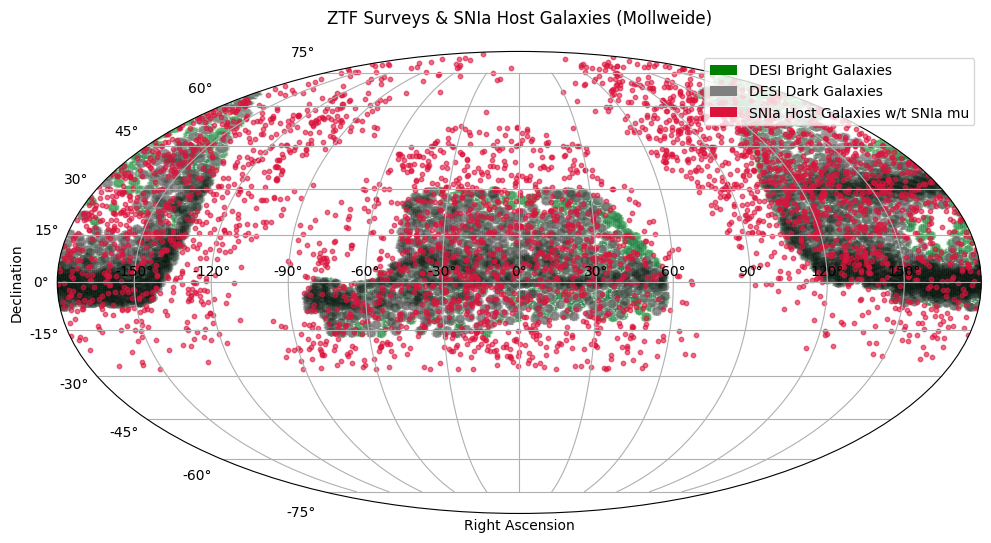

In [12]:
# === Load DESI Bright ===
bright = Table.read("DES5YR_DESI_data/desi_galaxy_metadata.fits")
ra_bright, dec_bright = prepare_coords(bright['RA'], bright['DEC'])

# === Load DESI Dark ===
dark = Table.read("DES5YR_DESI_data/desi_galaxy_metadata_dark.fits")
ra_dark, dec_dark = prepare_coords(dark['RA'], dark['DEC'])

# === Load SNIa Metadata CSV ===
sn_df = pd.read_csv("ZTF_DESI_data/ZTF_snia_with_hosts_AND_SALT2.csv")

# Filter out invalid host coordinates
valid_hosts = (sn_df['ra_host'] != -999) & (sn_df['dec_host'] != -999)
host_ra = sn_df.loc[valid_hosts, 'ra_host'].values
host_dec = sn_df.loc[valid_hosts, 'dec_host'].values
ra_host, dec_host = prepare_coords(host_ra, host_dec)

# === Plot ===
plt.figure(figsize=(13, 6))
ax = plt.subplot(111, projection='mollweide')

# Flatten arrays for hexbin
x_bright, y_bright = ra_bright.flatten(), dec_bright.flatten()
x_dark, y_dark = ra_dark.flatten(), dec_dark.flatten()
x_host, y_host = ra_host.flatten(), dec_host.flatten()

# Hexbin with LogNorm for density contrast

# DESI Bright (density)
hb1 = ax.hexbin(x_bright, y_bright, gridsize=500, cmap='Greens',
                mincnt=1, linewidths=0, norm=LogNorm())

# DESI Dark (density)
hb2 = ax.hexbin(x_dark, y_dark, gridsize=500, cmap='Greys',
                mincnt=1, linewidths=0, norm=LogNorm())

# SNIa Hosts (scatter instead of density)
ax.scatter(x_host, y_host, s=10, color='crimson', alpha=0.6, label='SNIa Host Galaxies w/t SNIa mu')

# Legend using dummy patches
legend_elements = [
    Patch(facecolor='green', label='DESI Bright Galaxies', alpha=1),
    Patch(facecolor='gray', label='DESI Dark Galaxies', alpha=1),
    Patch(facecolor='crimson', label='SNIa Host Galaxies w/t SNIa mu', alpha=1)
]
ax.legend(handles=legend_elements, loc='upper right')

# Plot settings
ax.set_title('ZTF Surveys & SNIa Host Galaxies (Mollweide)', pad=20)
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
ax.grid(True)
plt.show()

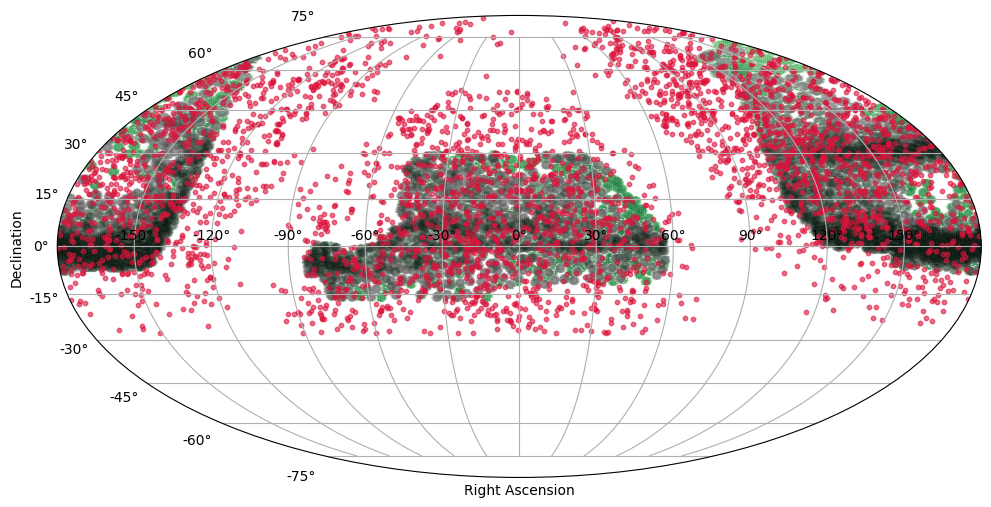

In [13]:
# === Load DESI Bright ===
bright = Table.read("DES5YR_DESI_data/desi_galaxy_metadata.fits")
ra_bright, dec_bright = prepare_coords(bright['RA'], bright['DEC'])

# === Load DESI Dark ===
dark = Table.read("DES5YR_DESI_data/desi_galaxy_metadata_dark.fits")
ra_dark, dec_dark = prepare_coords(dark['RA'], dark['DEC'])

# === Load SNIa Metadata CSV ===
sn_df = pd.read_csv("ZTF_DESI_data/ZTF_snia_with_hosts_AND_SALT2.csv")

# Filter out invalid host coordinates
valid_hosts = (sn_df['ra_host'] != -999) & (sn_df['dec_host'] != -999)
host_ra = sn_df.loc[valid_hosts, 'ra_host'].values
host_dec = sn_df.loc[valid_hosts, 'dec_host'].values
ra_host, dec_host = prepare_coords(host_ra, host_dec)

# === Plot ===
plt.figure(figsize=(13, 6))
ax = plt.subplot(111, projection='mollweide')

# Flatten arrays for hexbin
x_bright, y_bright = ra_bright.flatten(), dec_bright.flatten()
x_dark, y_dark = ra_dark.flatten(), dec_dark.flatten()
x_host, y_host = ra_host.flatten(), dec_host.flatten()

# Hexbin with LogNorm for density contrast

# DESI Bright (density)
hb1 = ax.hexbin(x_bright, y_bright, gridsize=500, cmap='Greens',
                mincnt=1, linewidths=0, norm=LogNorm())

# DESI Dark (density)
hb2 = ax.hexbin(x_dark, y_dark, gridsize=500, cmap='Greys',
                mincnt=1, linewidths=0, norm=LogNorm())

# SNIa Hosts (scatter instead of density)
ax.scatter(x_host, y_host, s=10, color='crimson', alpha=0.6, label='SNIa Host Galaxies w/t SNIa mu')



# Plot settings
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
ax.grid(True)
plt.show()

## General Strategy

1. **Compress light curves into 3 SALT2 numbers**  
   Each SN is reduced to $(x_0, x_1, c)$.  
   These are the parameters in my CSV file.

2. **Define a distance estimator (Tripp relation)**  
   $
   \mu_{\text{obs}} = -2.5\log_{10}x_0 + \alpha x_1 - \beta c + M_B
   $
   where $\alpha, \beta, M_B$ are unknown *global nuisance parameters*.

3. **Get the theoretical expectation from cosmology**  
   For each redshift $z$, compute  
   $
   \mu_{\text{th}}(z; \Omega_M,H_0) =
   5\log_{10}\!\left(\frac{d_L(z)}{10\ \mathrm{pc}}\right),
   $  
   where $d_L(z)$ is the luminosity distance in your chosen cosmology  
   (e.g. flat $\Lambda$CDM).  
   In practice, $M_B$ absorbs $H_0$, so $H_0$ is fixed to a convenient value. So that's all you need. These things are analytically marginalizable. 

4. **Compare observed vs. theory**  
   Define the residuals:  
   $
   \Delta\mu_i = \mu_{\text{obs},i} - \mu_{\text{th}}(z_i).
   $

5. **Fit the nuisance parameters $\alpha,\beta,M_B$**  
   Choose them to minimize scatter in the Hubble diagram, i.e. minimize  
   $
   \chi^2 = \sum_i \frac{\Delta\mu_i^2}{\sigma_i^2},
   $  
   where $\sigma_i^2$ is the per-SN variance (measurement error + peculiar velocity + intrinsic scatter).  
   This is exactly what the iterative weighted least squares + MLE update for 
   $\sigma_{\rm int}$ is doing in the code.


   Reminder that M_b H_o are analytically marignailizable just like the project we did before. 

7. **Visualize**  
   - Plot $\mu_{\text{obs}}$ vs. $z$ (the Hubble diagram), overlay $\mu_{\text{th}}(z)$.  
   - Plot residuals vs. $z$, $x_1$, and $c$.  
   - Plot a histogram of residuals to show the scatter.

## Matching Step ##

We match the DES SNIa to DESI host galaxies via reported SNIa host galaxy coordiantes as part of the DES5YR sample. Please note: that only the SNIa reported as red galaxies are matched as their host galaxy information was reported. Using `astropy.coordinates.SkyCoord.match_to_catalog_sky`, we find the nearest DESI source to each SN host and keep only matches with angular separation < **1 arcsec** (a conservative radius to limit chance associations). For the surviving pairs we (i) select the matching rows from both tables, (ii) record the on-sky separation in arcseconds (`ANGSEP_ARCSEC`), and (iii) horizontally stack the SN and DESI columns so that each row represents one SN–host match. Finally, we write the result to `DES5YR_DESI_data/SNIa_matched_2_DESI_gal.csv` and report the total number of matches.

In [11]:
# === Step 1: Load ZTF SNIA associated host Host Galaxy Location Data ===
des_sn_hostgal = pd.read_csv(
    "ZTF_DESI_data/ZTF_snia_with_hosts_AND_SALT2.csv"
)

# Filter for valid coordinates
## The purpose of these lines is to make sure to filter out the -999 vlaues in 
## the ra_host and dec_host. For some reason just sayin != -999 ends up 
## throwing an error.
sn_valid_mask = (
    (des_sn_hostgal["dec_host"] > -90) & (des_sn_hostgal["dec_host"] < 90) &
    (des_sn_hostgal["ra_host"] >= 0) & (des_sn_hostgal["ra_host"] < 360)
)

des_sn_valid = des_sn_hostgal[sn_valid_mask]

# Create SkyCoord for SN hosts
sn_coords = SkyCoord(
    ra=des_sn_valid["ra_host"].values * u.deg,
    dec=des_sn_valid["dec_host"].values * u.deg
)

# === Step 2: Load DESI Galaxy Metadata (Dark + Bright) ===
fits_paths = [
    "DES5YR_DESI_data/desi_galaxy_metadata_dark.fits",
    "DES5YR_DESI_data/desi_galaxy_metadata.fits"
]

desi_tables = [Table.read(path, hdu=1) for path in fits_paths]

# Combine dark + bright into one table
desi_data = vstack(desi_tables, join_type='exact')

# Create SkyCoord for DESI galaxies
desi_coords = SkyCoord(
    ra=desi_data["RA"] * u.deg,
    dec=desi_data["DEC"] * u.deg
)

# === Step 3: Match SN hosts to DESI galaxies ===
## for the coordiantes in sn_coords, find the closest object in `desi coords`
## For each SNIa idx[i] tells us which row in th desi_coords has the closest match.
## sep2d is the angluar separation on the sky of the planets and stuff. 
idx, sep2d, _ = sn_coords.match_to_catalog_sky(desi_coords)

# Define a mask that Keep matches within 1 arcsecond
## Note: this is a boolean separataor. 
max_sep = 1 * u.arcsec
match_mask = sep2d < max_sep

# === Step 4: Extract matched rows ===
## This takes the DataFrame of valid SNIa that have host info (des_sn_valid) and filters
## it down to only the rows where match_mask is True.
## Table.from_pandas converts the pandas data frame to an astropy TABLE in order to
## take advantage of the Table.hstack feature.

## For matched_desi. First applies the same match_mask filtering to the idx array.
## Now you have only the DESI row indices for SNe that passed the 1 arcsecond cutoff.

## NOTE: desi_data is already in astropy Table format from above.

matched_sn = Table.from_pandas(des_sn_valid[match_mask])
matched_desi = desi_data[idx[match_mask]]

# Add angular separation (arcsec) collumn
matched_sn["ANGSEP_ARCSEC"] = sep2d[match_mask].arcsec

# Join matched tables
## This works mostly b/c idx was used ot make the two Tables lined up perfectly.
## So we can just horizontally stack them next to each other.
matched = hstack([matched_sn, matched_desi])

# === Step 5: Save outputs ===
matched.write("ZTF_DESI_data/ZTF_snia_match_DESI_hostgal.csv", format="csv", overwrite=True)

print(f"✅ Matched {len(matched)} SN-host pairs within 1 arcsec.")

✅ Matched 780 SN-host pairs within 1 arcsec.


### Redshift Match ###

The thing about the **DES 5YR** data release is that we get several types of redshifts for every SNIa:

- **zHD** – Hubble Diagram Redshift (with CMB and VPEC corrections)  
- **zHDERR** – Hubble Diagram Redshift Uncertainty  
- **zCMB** – CMB Corrected Redshift  
- **zCMBERR** – CMB Corrected Redshift Uncertainty  
- **zHEL** – Heliocentric Redshift  
- **zHELERR** – Heliocentric Redshift Uncertainty

Here is a note about **`Z`** in DESI — it refers to a **spectroscopic** redshift:  

https://fastspecfit.readthedocs.io/en/stable/fastspec.html

- **Redrock** – The spectroscopic classification and redshift fitting pipeline for DESI spectra.  
- **Z** – Redshift based on Redrock or QuasarNet (for QSO targets only).  
- **ZWARN** – Redrock zwarning bit.



Descriptions of what Redrock or QuasarNet mean:

https://data.desi.lbl.gov/doc/glossary/?utm_source=chatgpt.com

### So? Which redshift out of the DES5YR should be used when comparing to DESI redshift? ###

Use **`zHEL`** from DES 5YR for direct comparison to DESI `Z`.  
Both are in the heliocentric frame and are minimally corrected, avoiding frame/conversion mismatches.  

In astronomy, **heliocentric** means "relative to the center of the Sun.

- **Heliocentric redshift (`zHEL`)** = observed redshift with Earth's orbital motion removed.
- Still includes other effects like the Sun's motion relative to the Cosmic Microwave Background (CMB) and galaxy peculiar velocities.

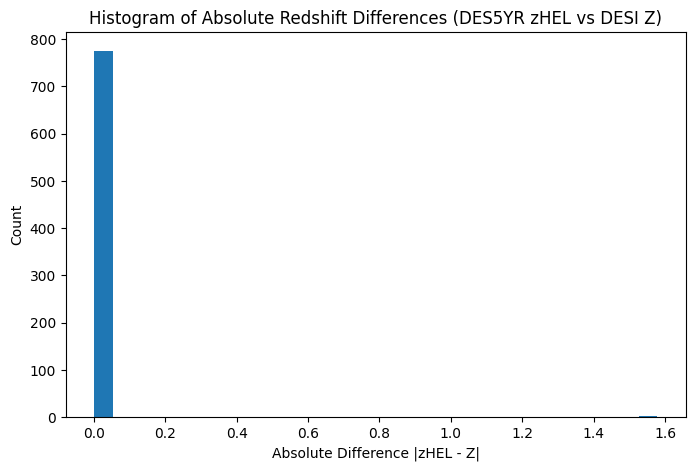

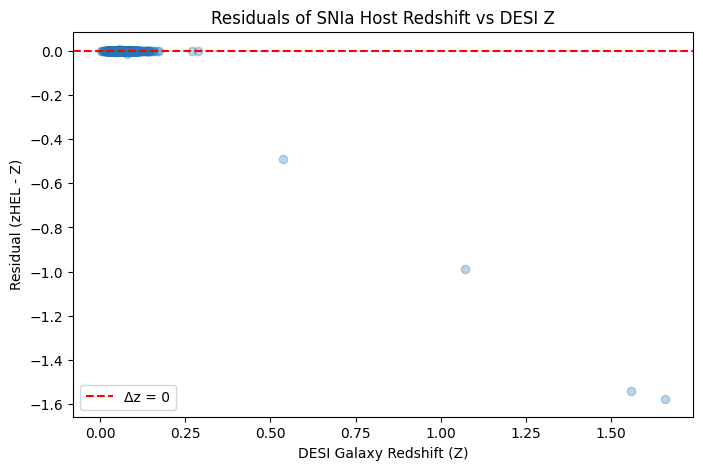

In [12]:
# === Load your CSV ===
csv_path = "ZTF_DESI_data/ZTF_snia_match_DESI_hostgal.csv" 
df = pd.read_csv(csv_path)

# === Calculate absolute difference between ZTF redshift and DESI Z ===
df["ABS_DIFF"] = (df["redshift"] - df["Z"]).abs()

# === Plot histogram ===
plt.figure(figsize=(8, 5))
plt.hist(df["ABS_DIFF"], bins=30)
plt.xlabel("Absolute Difference |zHEL - Z|")
plt.ylabel("Count")
plt.title("Histogram of Absolute Redshift Differences (DES5YR zHEL vs DESI Z)")
plt.show()

# Calculate residuals: DES5YR zHEL - DESI Z
df["RESIDUAL"] = df["redshift"] - df["Z"]

# Plot Residuals vs DESI Redshift
plt.figure(figsize=(8, 5))
plt.scatter(df["Z"], df["RESIDUAL"], alpha=0.3)
plt.axhline(0, color='r', linestyle='--', label='Δz = 0')
plt.xlabel("DESI Galaxy Redshift (Z)")
plt.ylabel("Residual (zHEL - Z)")
plt.title("Residuals of SNIa Host Redshift vs DESI Z")
plt.legend()
plt.show()

### Z - filter ###

It looks like some of our matches are actually pretty far away from each other in the redshift direction. We will discard any observations where |Δz| > 0.5. NOTE: this is something that was put in place during our class earlier in the spring w/t Jeff Newman. The reasoning behind the 0.5 cutoff is not well understod. Here is an elementary explanation behind it:


A **Δz ≈ 0.05** is actually *quite large* if we are talking about matching the **same galaxy** between the DES 5YR and DESI datasets.

**Why this is significant:**
- Typical **spectroscopic redshift precision** is on the order of *10⁻⁴ to 10⁻³* (differences of 0.0001–0.001), especially for galaxies with good signal-to-noise (S/N) spectra.
- A Δz = 0.05 corresponds to a velocity difference of roughly:

$$
\Delta v \approx c \times \frac{\Delta z}{1+z} \approx 15,000 \ \text{km/s} \quad (\text{for } z \sim 0.3)
$$

Such a large Δz often indicates:
- A mismatch between objects in the two catalogs (wrong galaxy matched).
- A poor-quality redshift measurement in one of the surveys.
- Different physical objects entirely (e.g., matching to a QSO instead of a galaxy).

776


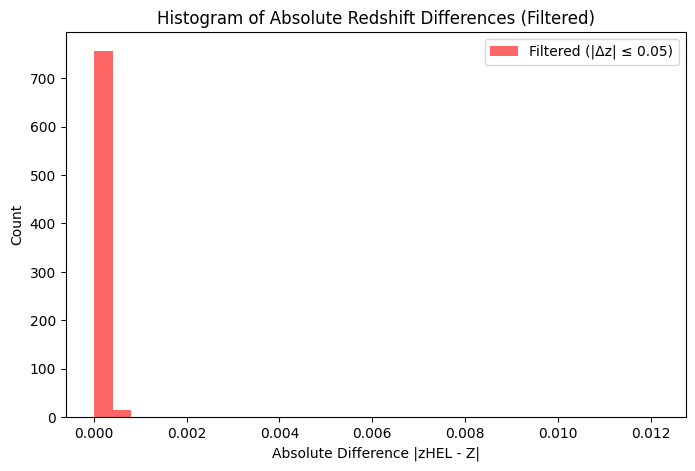

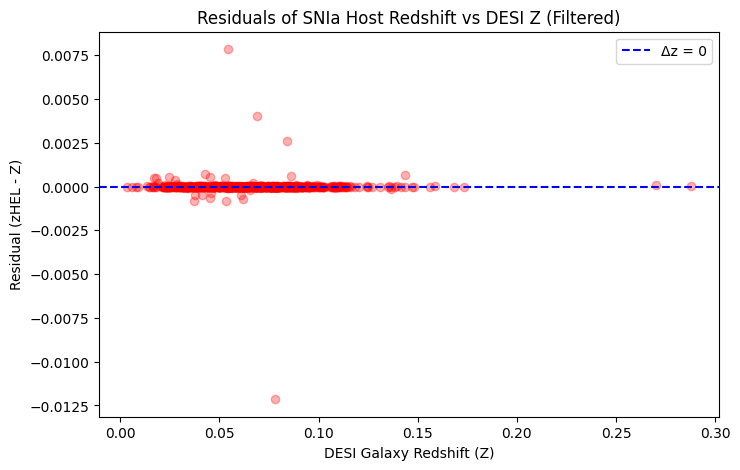

In [14]:
# === Then: Filter out rows where |Δz| > 0.05 ===
filtered_df = df[df["ABS_DIFF"] <= 0.05]
print(len(filtered_df))

# === Save the filtered data ===
output_path = "ZTF_DESI_data/ZTF_snia_match_DESI_hostgal_Z_filtered.csv"
filtered_df.to_csv(output_path, index=False)

# === Histogram AFTER filtering ===
plt.figure(figsize=(8, 5))
plt.hist(filtered_df["ABS_DIFF"], bins=30, alpha=0.6, color="red", label="Filtered (|Δz| ≤ 0.05)")
plt.xlabel("Absolute Difference |zHEL - Z|")
plt.ylabel("Count")
plt.title("Histogram of Absolute Redshift Differences (Filtered)")
plt.legend()
plt.show()

# === Verification plot: Residuals vs DESI Redshift for filtered data ===
plt.figure(figsize=(8, 5))
plt.scatter(filtered_df["Z"], filtered_df["RESIDUAL"], alpha=0.3, color = "red")
plt.axhline(0, color='b', linestyle='--', label='Δz = 0')
plt.xlabel("DESI Galaxy Redshift (Z)")
plt.ylabel("Residual (zHEL - Z)")
plt.title("Residuals of SNIa Host Redshift vs DESI Z (Filtered)")
plt.legend()
plt.show()

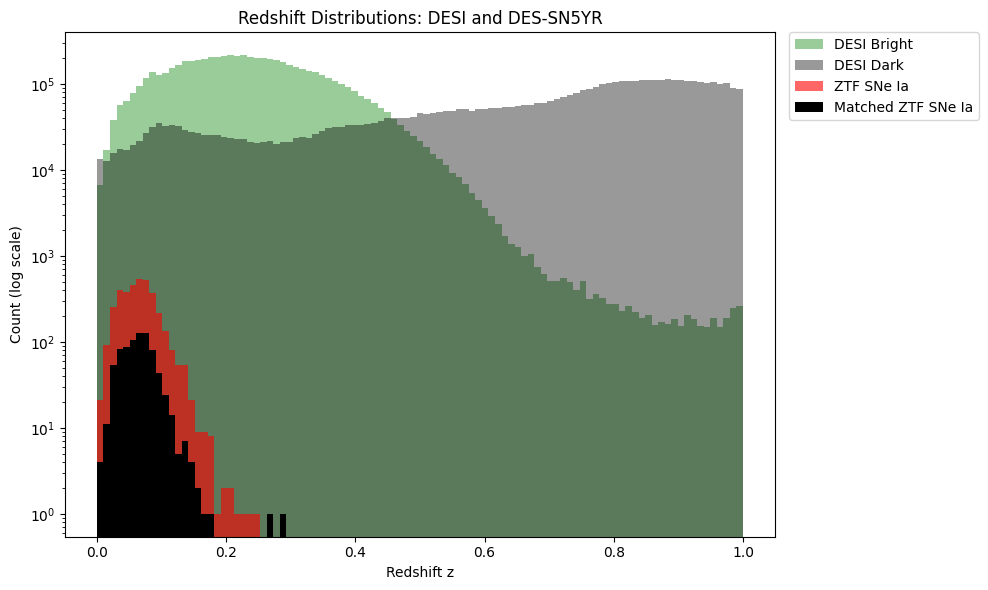

In [15]:
# ----------------------------
# Paths (adjust if needed)
# ----------------------------
DESI_BRIGHT_FITS = "DES5YR_DESI_data/desi_galaxy_metadata.fits"
DESI_DARK_FITS   = "DES5YR_DESI_data/desi_galaxy_metadata_dark.fits"
DES_SN_CSV       = "ZTF_DESI_data/ZTF_snia_data.csv"
MATCHED_CSV      = "ZTF_DESI_data/ZTF_snia_match_DESI_hostgal_Z_filtered.csv"

# ----------------------------
# Helper
# ----------------------------
def clean_numeric(series, finite_only=True):
    arr = pd.to_numeric(series, errors="coerce").to_numpy()
    if finite_only:
        arr = arr[np.isfinite(arr)]
    return arr

# ----------------------------
# Load DESI galaxy redshifts
# ----------------------------
desi_bright = Table.read(DESI_BRIGHT_FITS, hdu=1).to_pandas()
desi_dark   = Table.read(DESI_DARK_FITS,   hdu=1).to_pandas()

Z_bright = clean_numeric(desi_bright.get("Z", pd.Series([])))
Z_dark   = clean_numeric(desi_dark.get("Z", pd.Series([])))

# ----------------------------
# Load ZTF SNIa
# ----------------------------
des_sn = pd.read_csv(DES_SN_CSV)
zHEL_all = clean_numeric(des_sn.get("redshift", pd.Series([])))

# ----------------------------
# Load matched SNe
# ----------------------------
matched = pd.read_csv(MATCHED_CSV)
zHEL_matched = clean_numeric(matched.get("redshift", pd.Series([])))

# ----------------------------
# Plot: all distributions together
# ----------------------------
zmin, zmax = 0.0, 1.0
bins = np.linspace(zmin, zmax, 100)

plt.figure(figsize=(10, 6))
plt.hist(Z_bright, bins=bins, alpha=0.4, label="DESI Bright", color = "green", log=True)
plt.hist(Z_dark, bins=bins, alpha=0.4, label="DESI Dark", color = "black", log=True)
plt.hist(zHEL_all, bins=bins, alpha=0.6, label="ZTF SNe Ia", color = "red", log=True)
plt.hist(zHEL_matched, bins=bins, label="Matched ZTF SNe Ia", color = "black", log=True)

plt.xlabel("Redshift z")
plt.ylabel("Count (log scale)")
plt.title("Redshift Distributions: DESI and DES-SN5YR")
plt.legend(
    loc="upper left", 
    bbox_to_anchor=(1.02, 1),   # push legend just outside to the right
    borderaxespad=0
)
plt.tight_layout()
plt.show()

739


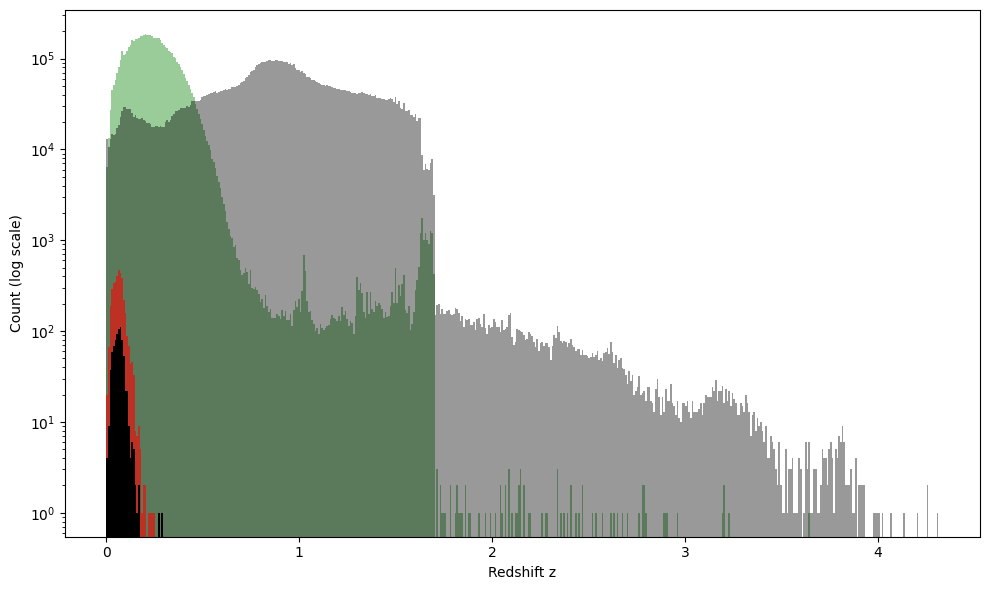

In [16]:
# ----------------------------
# Build shared bins from ALL redshifts (no cutoffs)
# ----------------------------
arrays = [Z_bright, Z_dark, zHEL_all, zHEL_matched]
nonempty = [a for a in arrays if a.size > 0]
all_z = np.concatenate(nonempty) if nonempty else np.array([])

# Safety: if everything's empty, skip; otherwise compute edges from data
if all_z.size == 0:
    raise ValueError("No redshift values found after cleaning.")

# Option A (recommended): data-driven binning (Freedman–Diaconis)
bins = np.histogram_bin_edges(all_z, bins="fd")
print(len(bins))
bins = np.linspace(all_z.min(), all_z.max(), 500)


# Fallback: if FD returns <2 edges (e.g., tiny sample), use a simple linspace
if bins.size < 2:
    zmin, zmax = float(all_z.min()), float(all_z.max())
    if zmin == zmax:
        zmax = zmin + 1e-6
    bins = np.linspace(zmin, zmax, 100)

plt.figure(figsize=(10, 6))
plt.hist(Z_bright, bins=bins, alpha=0.4, label="DESI Bright", color="green", log=True)
plt.hist(Z_dark,   bins=bins, alpha=0.4, label="DESI Dark",   color="black", log=True)
plt.hist(zHEL_all, bins=bins, alpha=0.6, label="DES-SN5YR SNe Ia", color="red", log=True)
plt.hist(zHEL_matched, bins=bins, label="Matched SNe Ia", color="black", log=True)

plt.xlabel("Redshift z")
plt.ylabel("Count (log scale)")
plt.tight_layout()
plt.show()

Fitted (global scalars):
  alpha = 0.138 ± 0.004
  beta  = 2.841 ± 0.029
  M_B   = 29.756 ± 0.004
  sigma_int = 0.195  |  chi2/dof = 1.03


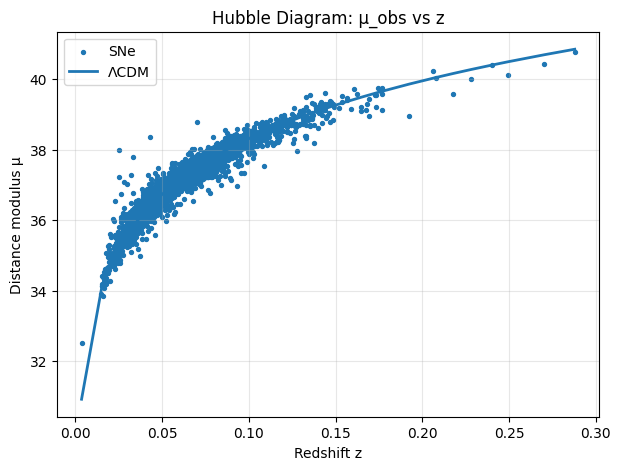

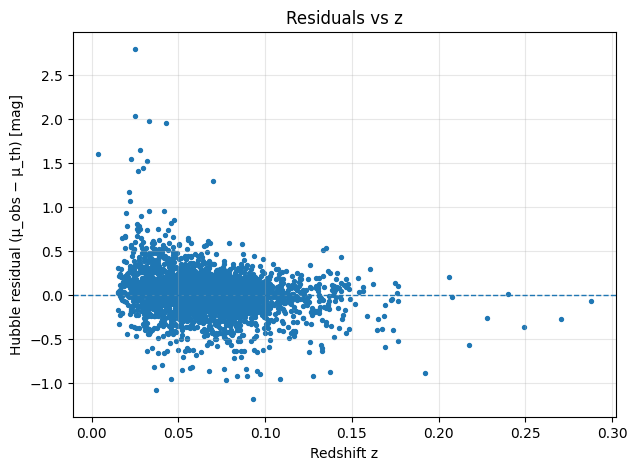

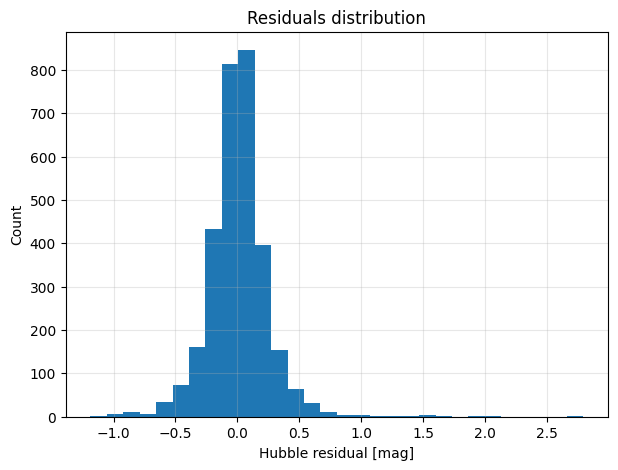

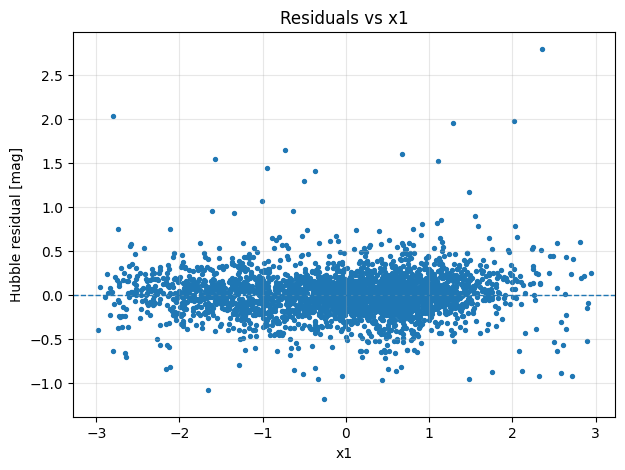

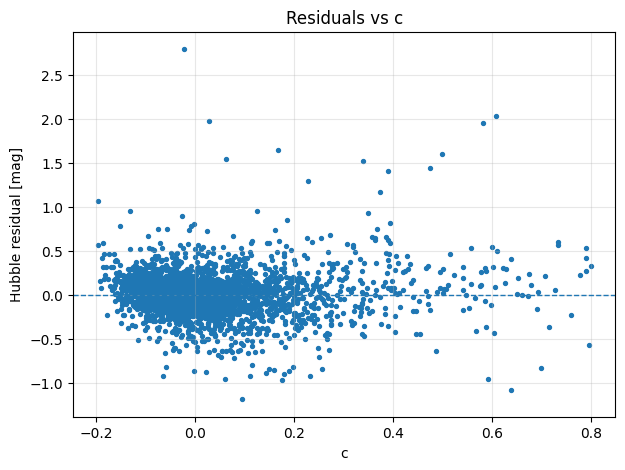

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from astropy.cosmology import FlatLambdaCDM

# =========================
# CONFIG
# =========================
CSV = "ZTF_DESI_data/ZTF_snia_with_hosts_AND_SALT2.csv"
H0, OM0 = 70.0, 0.3          # cosmology for mu_th (MB absorbs H0 offset)
SIGMA_V = 300.0              # km/s peculiar velocity scatter
CUTS = dict(x1=(-3, 3), c=(-0.2, 0.8), fitprob_min=1e-7)

LOG10E = 1/np.log(10)

def mu0_from_x0(x0):
    """-2.5 log10 x0"""
    return -2.5*np.log10(x0)

def fit_alpha_beta_MB(df):
    # -------- Basic quality cuts --------
    mask = (
        np.isfinite(df["x0"]) & (df["x0"] > 0) &
        np.isfinite(df["x1"]) & np.isfinite(df["c"]) &
        np.isfinite(df["x0_err"]) & np.isfinite(df["x1_err"]) & np.isfinite(df["c_err"]) &
        np.isfinite(df["redshift"]) & (df["redshift"] > 0)
    )
    if "fitprob" in df.columns:
        mask &= (df["fitprob"] >= CUTS["fitprob_min"])
    mask &= df["x1"].between(*CUTS["x1"]) & df["c"].between(*CUTS["c"])
    d = df.loc[mask].copy()
    if len(d) < 10:
        raise ValueError(f"Too few SNe after cuts: {len(d)}")

    # -------- Columns --------
    x0, x1, c = d["x0"].values, d["x1"].values, d["c"].values
    x0e, x1e, ce = d["x0_err"].values, d["x1_err"].values, d["c_err"].values
    z = d["redshift"].values
    ze = d.get("redshift_err", pd.Series(np.zeros(len(d)), index=d.index)).values

    # Covariances (fill with zeros if missing)
    cov_x0_x1 = d.get("cov_x0_x1", pd.Series(np.zeros(len(d)), index=d.index)).values
    cov_x0_c  = d.get("cov_x0_c",  pd.Series(np.zeros(len(d)), index=d.index)).values
    cov_x1_c  = d.get("cov_x1_c",  pd.Series(np.zeros(len(d)), index=d.index)).values

    # -------- Cosmology & targets --------
    cosmo = FlatLambdaCDM(H0=H0, Om0=OM0)
    mu_th = cosmo.distmod(z).value
    mu0 = mu0_from_x0(x0)
    t = mu_th - mu0                      # target for linear part
    X = np.column_stack([x1, -c, np.ones_like(x1)])  # columns: [x1, -c, 1], shape (N,3)

    # -------- Variance helpers --------
    def sigma_meas_sq(alpha, beta):
        dmu_dx0 = -2.5*LOG10E*(1.0/x0)
        dmu_dx1 = alpha
        dmu_dc  = -beta
        var = (
            (dmu_dx0**2)*x0e**2 +
            (dmu_dx1**2)*x1e**2 +
            (dmu_dc**2)*ce**2 +
            2*dmu_dx0*dmu_dx1*cov_x0_x1 +
            2*dmu_dx0*dmu_dc *cov_x0_c  +
            2*dmu_dx1*dmu_dc *cov_x1_c
        )
        return np.clip(var, 0, None)

    def sigma_pv_sq():
        c_kms = 299_792.458
        term = (5/np.log(10))*(SIGMA_V/(c_kms*np.clip(z, 1e-4, None)))
        return term**2

    def sigma_z_sq():
        dz = np.maximum(ze, 1e-5)
        mu_p = FlatLambdaCDM(H0=H0, Om0=OM0).distmod(z+dz).value
        mu_m = FlatLambdaCDM(H0=H0, Om0=OM0).distmod(np.clip(z-dz, 1e-6, None)).value
        dmu_dz = (mu_p - mu_m)/(2*dz)
        return (dmu_dz*ze)**2

    # -------- Iterative WLS + sigma_int MLE --------
    alpha, beta, MB = 0.15, 3.0, -19.3   # initial guess
    sigma_int = 0.1
    for _ in range(6):
        v_meas = sigma_meas_sq(alpha, beta)
        v_tot = v_meas + sigma_pv_sq() + sigma_z_sq() + sigma_int**2
        w = 1.0/np.clip(v_tot, 1e-12, None)

        # Weighted least squares: ensure RHS is 1-D
        W = np.sqrt(w)[:, None]         # (N,1)
        Xw = W * X                      # (N,3)
        tw = (W[:, 0] * t)              # (N,)  <-- 1-D RHS
        theta, *_ = np.linalg.lstsq(Xw, tw, rcond=None)
        theta = np.asarray(theta).ravel()    # (3,)
        alpha, beta, MB = theta.tolist()     # scalars

        # MLE for sigma_int
        def nll(log_s):
            s = np.exp(log_s)
            v = v_meas + sigma_pv_sq() + sigma_z_sq() + s**2
            r = t - (alpha*x1 - beta*c + MB)
            return 0.5*np.sum(np.log(2*np.pi*np.clip(v,1e-12,None)) + (r*r)/np.clip(v,1e-12,None))
        res = minimize(nll, x0=np.log(max(sigma_int,1e-4)),
                       bounds=[(np.log(1e-4), np.log(0.5))])
        sigma_int = float(np.exp(res.x[0]))

    # -------- Parameter covariance from final WLS --------
    v_meas = sigma_meas_sq(alpha, beta)
    v_tot = v_meas + sigma_pv_sq() + sigma_z_sq() + sigma_int**2
    w = 1.0/np.clip(v_tot, 1e-12, None)
    XtWX = (X.T * w) @ X
    cov = np.linalg.inv(XtWX)
    se_alpha, se_beta, se_MB = np.sqrt(np.diag(cov))

    mu_obs = mu0 + alpha*x1 - beta*c + MB
    resid = mu_obs - mu_th
    chi2 = np.sum(w*resid*resid)
    ndof = len(resid) - 3

    out = dict(
        alpha=float(alpha), alpha_err=float(se_alpha),
        beta=float(beta),   beta_err=float(se_beta),
        MB=float(MB),       MB_err=float(se_MB),
        sigma_int=float(sigma_int),
        chi2_dof=float(chi2/max(ndof,1)),
        z=z, mu_obs=mu_obs, mu_th=mu_th,
        resid=resid, x1=x1, c=c
    )
    return out

# =========================
# RUN
# =========================
df = pd.read_csv(CSV)
res = fit_alpha_beta_MB(df)

print("Fitted (global scalars):")
print(f"  alpha = {res['alpha']:.3f} ± {res['alpha_err']:.3f}")
print(f"  beta  = {res['beta']:.3f} ± {res['beta_err']:.3f}")
print(f"  M_B   = {res['MB']:.3f} ± {res['MB_err']:.3f}")
print(f"  sigma_int = {res['sigma_int']:.3f}  |  chi2/dof = {res['chi2_dof']:.2f}")

# =========================
# PLOTS
# =========================
z, mu_obs, mu_th = res["z"], res["mu_obs"], res["mu_th"]
resid, x1, c = res["resid"], res["x1"], res["c"]

# 1) Hubble diagram
plt.figure(figsize=(7,5))
plt.scatter(z, mu_obs, s=8, label="SNe")
idx = np.argsort(z)
plt.plot(z[idx], mu_th[idx], label="ΛCDM", linewidth=2)
plt.xlabel("Redshift z")
plt.ylabel("Distance modulus μ")
plt.title("Hubble Diagram: μ_obs vs z")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 2) Residuals vs z
plt.figure(figsize=(7,5))
plt.scatter(z, resid, s=8)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Redshift z")
plt.ylabel("Hubble residual (μ_obs − μ_th) [mag]")
plt.title("Residuals vs z")
plt.grid(True, alpha=0.3)
plt.show()

# 3) Residuals histogram
plt.figure(figsize=(7,5))
plt.hist(resid, bins=30)
plt.xlabel("Hubble residual [mag]")
plt.ylabel("Count")
plt.title("Residuals distribution")
plt.grid(True, alpha=0.3)
plt.show()

# 4a) Residuals vs x1
plt.figure(figsize=(7,5))
plt.scatter(x1, resid, s=8)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("x1")
plt.ylabel("Hubble residual [mag]")
plt.title("Residuals vs x1")
plt.grid(True, alpha=0.3)
plt.show()

# 4b) Residuals vs c
plt.figure(figsize=(7,5))
plt.scatter(c, resid, s=8)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("c")
plt.ylabel("Hubble residual [mag]")
plt.title("Residuals vs c")
plt.grid(True, alpha=0.3)
plt.show()